In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_parquet("/Users/davipultrini/Documents/studies/python_projects/StudingDataScience/bank_datascience/src/dataset_risco_credito_final.parquet")

display(df.head())

,CNPJ_CIA,DENOM_CIA,DT_FIM_EXERC,VL_CONTA,target_lucro,ano_mes,selic_media_mensal,selic_maxima_mensal,selic_volatilidade,data_referencia,valor,ipca_aceleracao,ipca_acc_3m,ipca_acc_12m,SETOR_ATIV
0,00.000.000/0001-91,BCO BRASIL S.A.,2023-03-31,7290982.0,1,2023-03,0.050788,0.050788,0.00000,2023-03-01,0.71,-0.13,2.08,4.57,Bancos
1,00.000.000/0001-91,BCO BRASIL S.A.,2023-06-30,16383496.0,1,2023-06,0.050788,0.050788,0.00000,2023-06-01,-0.08,-0.31,0.76,3.13,Bancos
2,00.000.000/0001-91,BCO BRASIL S.A.,2023-09-30,25225143.0,1,2023-09,0.048422,0.049037,0.00086,2023-09-01,0.26,0.03,0.61,5.07,Bancos
3,00.000.208/0001-00,BRB BANCO DE BRASILIA S.A.,2023-03-31,-93027.0,0,2023-03,0.050788,0.050788,0.00000,2023-03-01,0.71,-0.13,2.08,4.57,Bancos
4,00.000.208/0001-00,BRB BANCO DE BRASILIA S.A.,2023-06-30,117859.0,1,2023-06,0.050788,0.050788,0.00000,2023-06-01,-0.08,-0.31,0.76,3.13,Bancos


In [31]:
data_de_corte = '2025-07'
periodo_corte = pd.Period(data_de_corte, freq='M')

df_treino = df[df['ano_mes'] < periodo_corte].copy()
df_teste = df[df['ano_mes'] >= periodo_corte].copy()

print(f"Linhas em Treino: {len(df_treino)}")
print(f"Linhas em Teste: {len(df_teste)}")

Linhas em Treino: 2259
Linhas em Teste: 448


--- Distribuição do Target no Treino ---


target_lucro
1    68.13
0    31.87
Name: proportion, dtype: float64

/var/folders/gl/bhv5rjy94kn9tm062g928rk80000gn/T/ipykernel_77326/1847163688.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


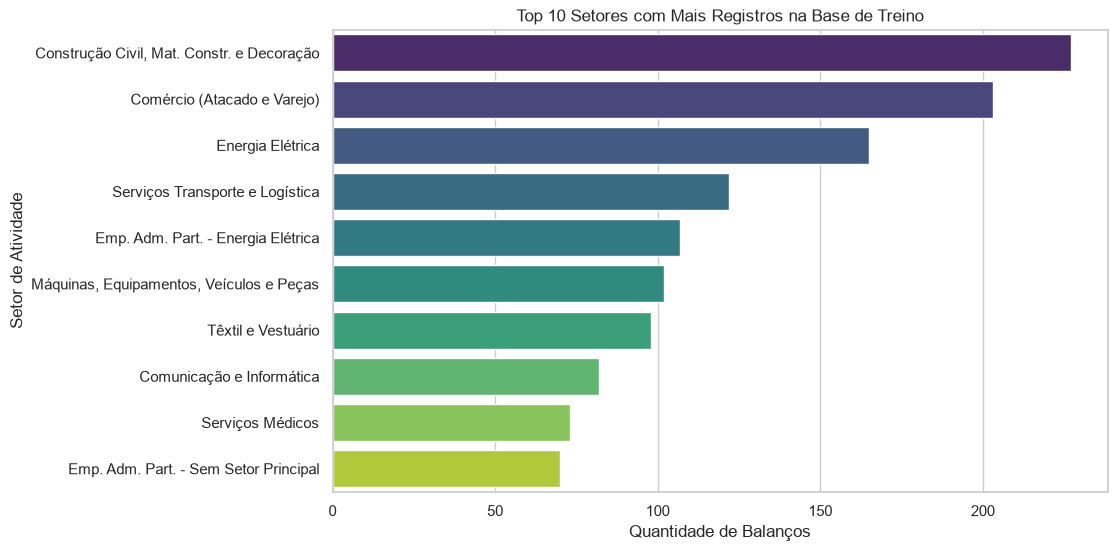

In [32]:
print("--- Distribuição do Target no Treino ---")
display(df_treino['target_lucro'].value_counts(normalize=True).round(4) * 100)

# Gráfico dos Maiores Setores da Bolsa
plt.figure(figsize=(10, 6))
top_setores = df_treino['SETOR_ATIV'].value_counts().index[:10]

sns.countplot(
    data=df_treino,
    y='SETOR_ATIV',
    order=top_setores,
    palette='viridis'
)
plt.title("Top 10 Setores com Mais Registros na Base de Treino")
plt.xlabel("Quantidade de Balanços")
plt.ylabel("Setor de Atividade")
plt.show()

Analisando correlação apenas para o setor: Construção Civil, Mat. Constr. e Decoração


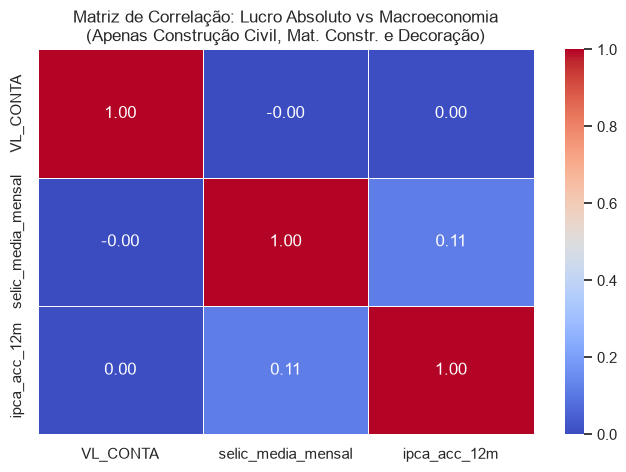

In [36]:
setor_alvo = df_treino['SETOR_ATIV'].value_counts().index[0]
print(f"Analisando correlação apenas para o setor: {setor_alvo}")

df_setor = df_treino[df_treino['SETOR_ATIV'] == setor_alvo]

# Calcula a correlação com as features numéricas
colunas_correlacao = ['VL_CONTA', 'selic_media_mensal', 'ipca_acc_12m']
df_heatmap = df_setor[colunas_correlacao].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(df_heatmap, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title(f'Matriz de Correlação: Lucro Absoluto vs Macroeconomia\n(Apenas {setor_alvo})')
plt.show()

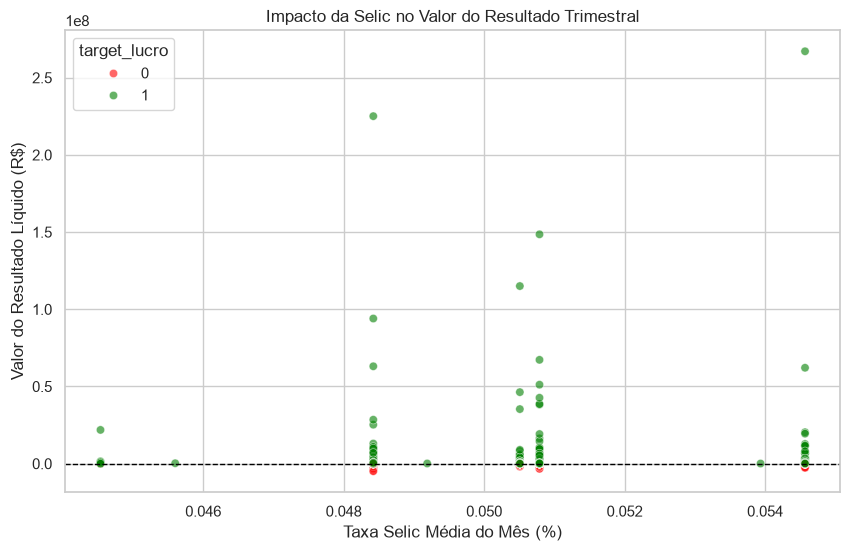

In [37]:
plt.figure(figsize=(10, 6))

# Usamos o hue para pintar as bolinhas com cores diferentes se for Lucro ou Prejuízo
sns.scatterplot(
    data=df_treino,
    x='selic_media_mensal',
    y='VL_CONTA',
    hue='target_lucro',
    palette={1: 'green', 0: 'red'},
    alpha=0.6
)

# Adicionamos uma linha no zero para dividir quem lucrou de quem teve prejuízo
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title('Impacto da Selic no Valor do Resultado Trimestral')
plt.xlabel('Taxa Selic Média do Mês (%)')
plt.ylabel('Valor do Resultado Líquido (R$)')
plt.show()

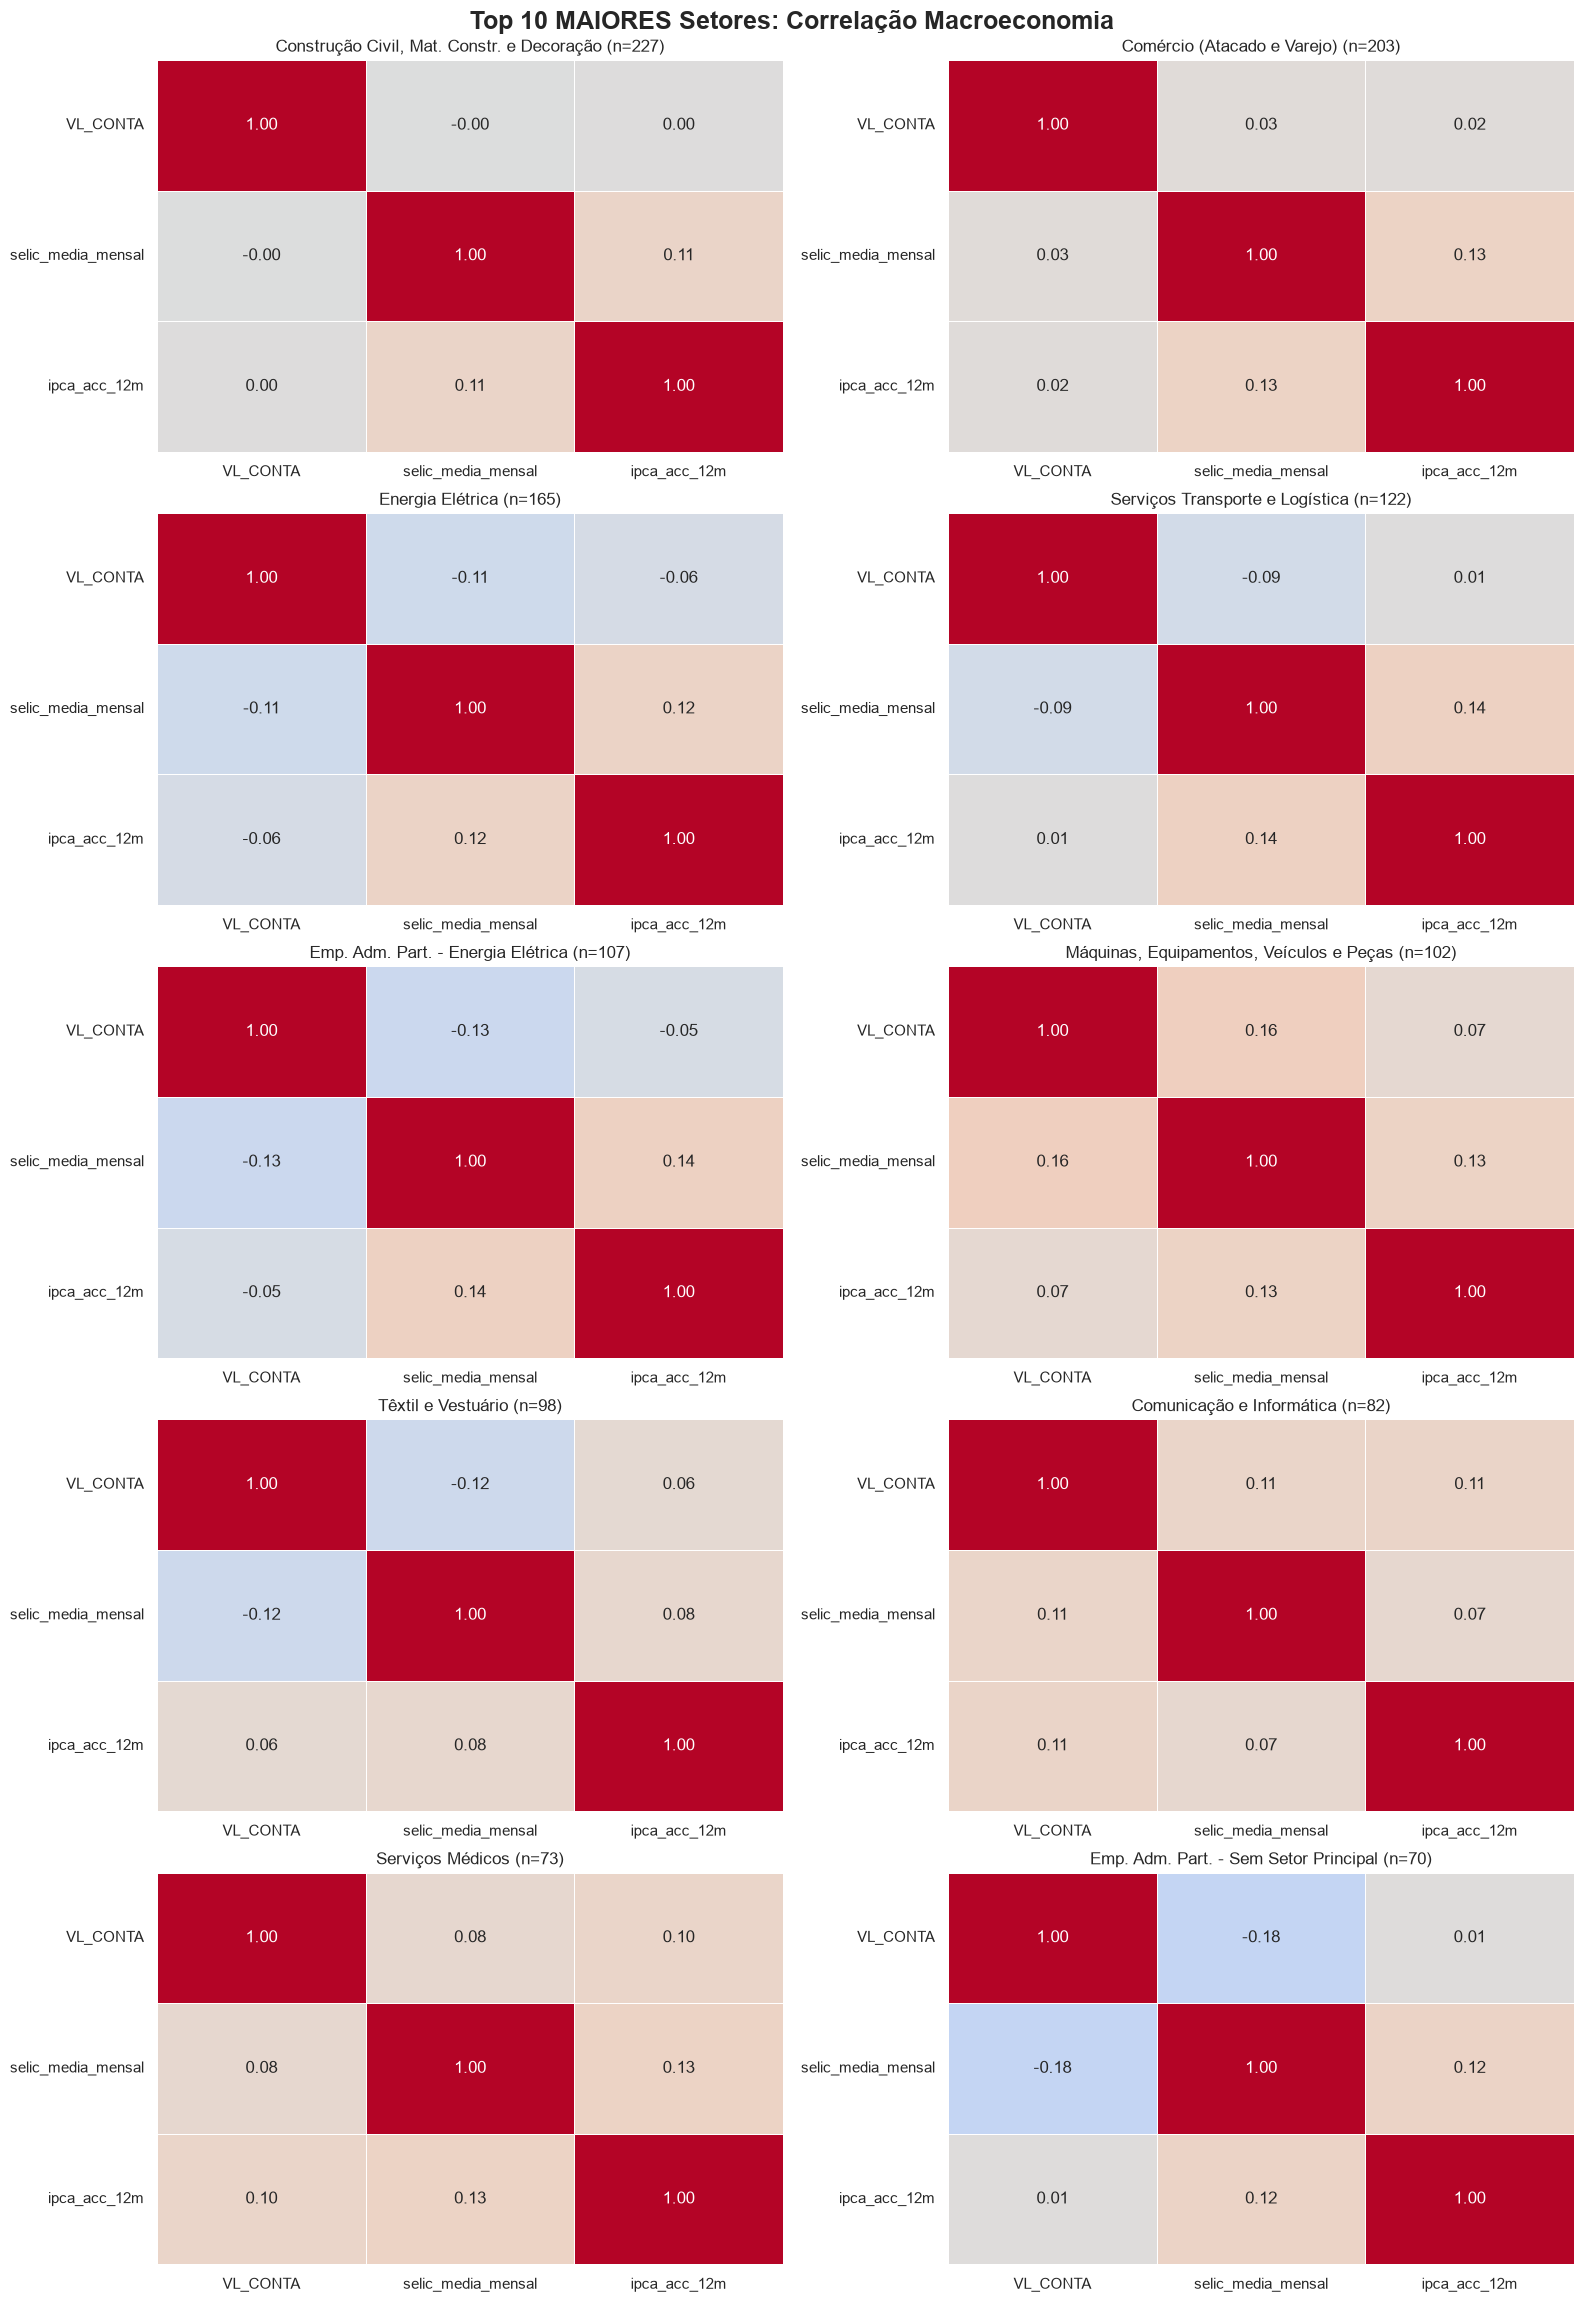

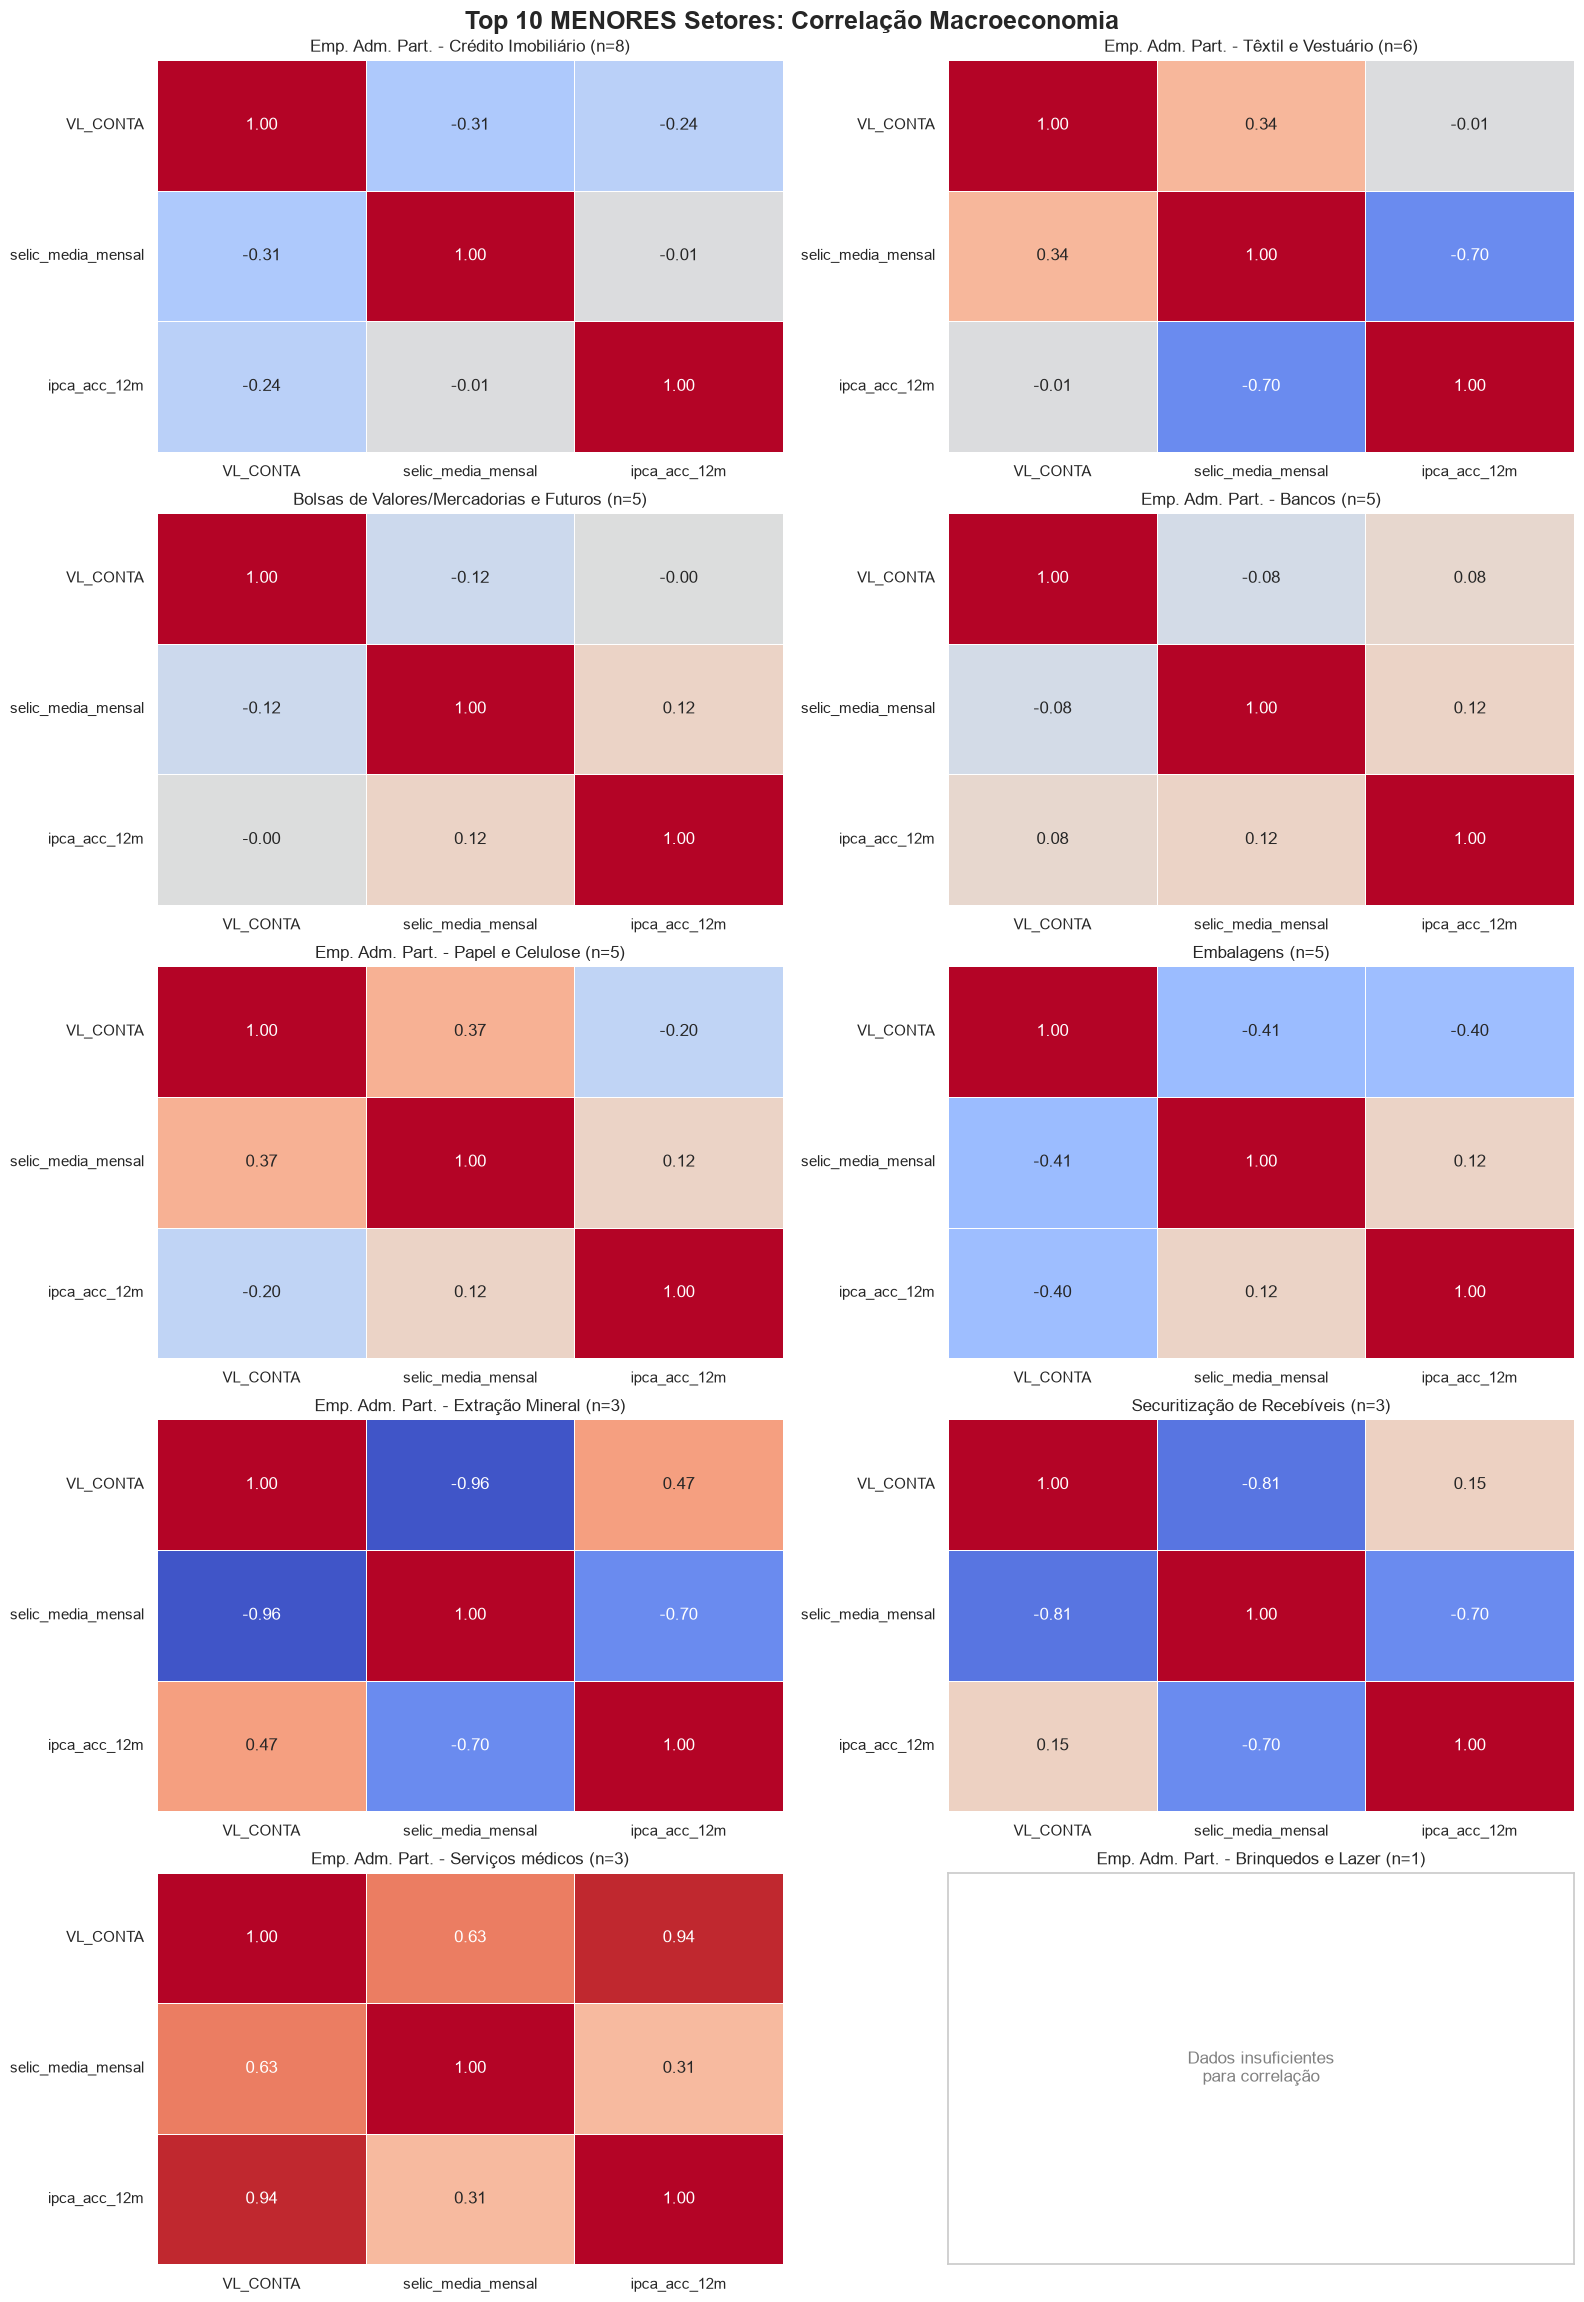

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

contagem_setores = df_treino['SETOR_ATIV'].value_counts()
top_10_setores = contagem_setores.head(10).index.tolist()
bottom_10_setores = contagem_setores.tail(10).index.tolist()

colunas_correlacao = ['VL_CONTA', 'selic_media_mensal', 'ipca_acc_12m']

def plotar_grid_correlacao(lista_setores, titulo_principal):
    """Cria um grid 5x2 de heatmaps para uma lista de 10 setores."""

    # Prepara o tamanho do painel (figsize grande para acomodar tudo sem amassar)
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 25))
    fig.suptitle(titulo_principal, fontsize=18, y=0.92, fontweight='bold')

    # Transforma a matriz 5x2 de posições de gráfico em uma lista simples de 10 posições
    axes = axes.flatten()

    for i, setor in enumerate(lista_setores):
        ax = axes[i]

        # Filtra os dados apenas para o setor da vez
        df_setor = df_treino[df_treino['SETOR_ATIV'] == setor]
        n_registros = len(df_setor)

        # A correlação só funciona estatisticamente se tivermos variância mínima
        if n_registros > 2:
            df_heatmap = df_setor[colunas_correlacao].corr()

            # Se a correlação gerar NaNs por falta de variação no lucro, substituímos por zero
            df_heatmap = df_heatmap.fillna(0)

            sns.heatmap(
                df_heatmap,
                annot=True,
                cmap='coolwarm',
                fmt=".2f",
                linewidths=0.5,
                ax=ax,
                cbar=False,
                vmin=-1, vmax=1
            )
        else:
            # Painel em branco para setores muito pequenos que não têm dados suficientes
            ax.text(0.5, 0.5, 'Dados insuficientes\npara correlação',
                    ha='center', va='center', fontsize=12, color='grey')
            ax.set_xticks([])
            ax.set_yticks([])

        ax.set_title(f'{setor} (n={n_registros})', fontsize=12)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90) # Dá um respiro entre o título e os gráficos
    plt.show()

# 2. Executa a função para os Maiores Setores
plotar_grid_correlacao(top_10_setores, 'Top 10 MAIORES Setores: Correlação Macroeconomia')

# 3. Executa a função para os Menores Setores
plotar_grid_correlacao(bottom_10_setores, 'Top 10 MENORES Setores: Correlação Macroeconomia')

# Análises básicas do EDA
1. O gráfico de dispersão mostra que há uma grande concentração de empresas com faturamentos médios/pequenos, exceto por alguns outliers com faturamentos na casa de centenas de milhões. Isso se deve pois estamos falando de gigantes do mercado (Petobras, Vale, Bancos...).
2. Os setores que mais sofreram com a taxa de juros temos empresas de energia Elétrica e Emp. Adm. Part. - Sem setor principal, a correlação deles se mostram negativo. Essas empresas (menores) tendem a sofrer com as taxas de juros. Além disso, não há linearidade direta com o aumento de juros. Empresas podem ter lucros grandes em curto prazo, mas em longo prazo os clientes param de comprar.

## Observações
Neste caso, não vale a pena usar modelos de regressão (lineares simples), uma vez que os dados são complexos e assimétricos e cheios de nuances por setor.
